<a href="https://colab.research.google.com/github/crowell97/ES5201/blob/main/ES5201_Lecture13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tomography Resolution & Earthquake Location — A Companion Notebook

**EARTH 5201 — Introduction to Seismology**

**The Ohio State University**

**Companion notebook to Lecture 13 — Tomography Resolution & Earthquake Location**

This notebook implements the two major tools from lecture:

1. **A checkerboard resolution test** — reusing the tomography G-matrix machinery from Lecture 12, comparing recovery under good vs. poor ray coverage.
2. **Earthquake location** — a full nonlinear grid search, then the linearized (Gauss-Newton) iterative alternative, and a demonstration of why relative location between nearby events beats absolute location.

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pylab as plt

plt.rcParams["figure.figsize"] = (8, 6)

## Part 1 — A Checkerboard Resolution Test

We reuse the block/ray tomography setup from Lecture 12: trace straight rays through a grid, build the sparse G matrix, then see how well a checkerboard pattern survives the round trip through forward modeling and damped-least-squares inversion.

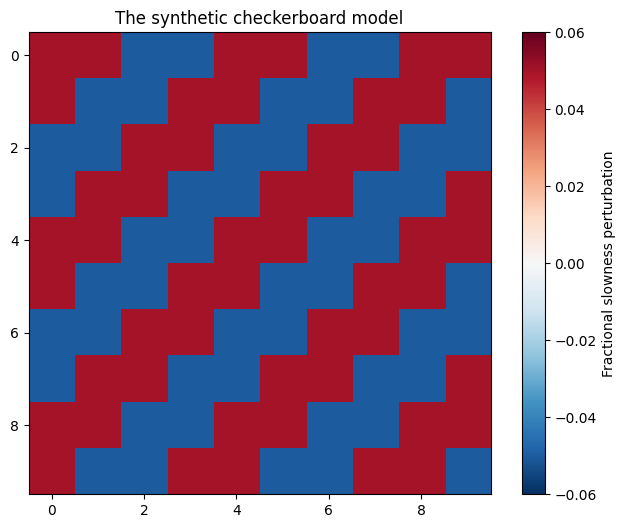

In [2]:
def ray_block_lengths(src, rcv, n_blocks, n_steps=3000):
    lengths = np.zeros((n_blocks, n_blocks))
    pts = np.linspace(src, rcv, n_steps)
    ds = np.linalg.norm(np.array(rcv) - np.array(src)) / n_steps
    for x, y in pts:
        i, j = int(y), int(x)
        if 0 <= i < n_blocks and 0 <= j < n_blocks:
            lengths[i, j] += ds
    return lengths.flatten()

n = 10
checker = np.indices((n, n)).sum(axis=0) // 2 % 2
checker = np.where(checker == 0, 0.05, -0.05).astype(float)

plt.imshow(checker, cmap="RdBu_r", vmin=-0.06, vmax=0.06)
plt.title("The synthetic checkerboard model")
plt.colorbar(label="Fractional slowness perturbation")
plt.show()

In [3]:
def make_rays(n_rays, mode, n_blocks, seed=0):
    rng = np.random.default_rng(seed)
    srcs, rcvs = [], []
    for _ in range(n_rays):
        edge_pair = rng.choice(4, size=2, replace=False) if mode == "good" else [0, 1]
        def edge_point(e):
            t = rng.uniform(0, n_blocks)
            return [(0, t), (n_blocks, t), (t, 0), (t, n_blocks)][e]
        srcs.append(edge_point(edge_pair[0]))
        rcvs.append(edge_point(edge_pair[1]))
    return np.array(srcs), np.array(rcvs)

def run_checkerboard_test(mode, lam=0.08, n_rays=120, seed=7):
    srcs, rcvs = make_rays(n_rays, mode, n, seed=seed)
    G = np.array([ray_block_lengths(s, r, n) for s, r in zip(srcs, rcvs)])
    rng = np.random.default_rng(seed)
    d_obs = G @ checker.flatten() + rng.normal(0, 0.002, size=G.shape[0])
    A = np.vstack([G, lam * np.eye(G.shape[1])])
    b = np.concatenate([d_obs, np.zeros(G.shape[1])])
    m_rec, *_ = np.linalg.lstsq(A, b, rcond=None)
    return m_rec.reshape(n, n), G

Correlation with true model -- good coverage: 0.998
Correlation with true model -- poor coverage: 0.970


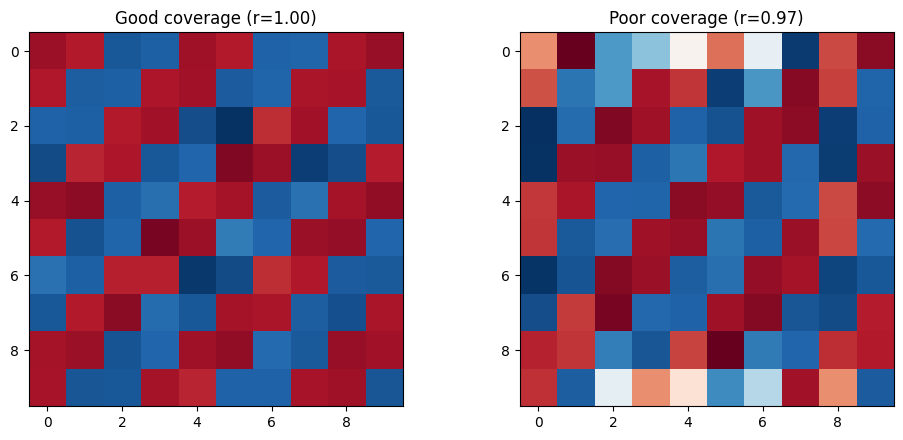

In [4]:
recovered_good, G_good = run_checkerboard_test("good")
recovered_poor, G_poor = run_checkerboard_test("poor")

# Quantify recovery quality: correlation with the true checkerboard
corr_good = np.corrcoef(checker.flatten(), recovered_good.flatten())[0, 1]
corr_poor = np.corrcoef(checker.flatten(), recovered_poor.flatten())[0, 1]
print(f"Correlation with true model -- good coverage: {corr_good:.3f}")
print(f"Correlation with true model -- poor coverage: {corr_poor:.3f}")
assert corr_good > corr_poor, "Good ray coverage should recover the checkerboard better"

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].imshow(recovered_good, cmap="RdBu_r", vmin=-0.06, vmax=0.06)
axes[0].set_title(f"Good coverage (r={corr_good:.2f})")
axes[1].imshow(recovered_poor, cmap="RdBu_r", vmin=-0.06, vmax=0.06)
axes[1].set_title(f"Poor coverage (r={corr_poor:.2f})")
plt.tight_layout()
plt.show()

As expected, good angular ray coverage recovers the checkerboard pattern with a much higher correlation to the true model than rays confined to a single direction — a direct, quantitative demonstration of why resolution tests matter before trusting a tomographic image.

## Part 2 — Earthquake Location: A Full Grid Search

Now the second major inverse problem from lecture. We'll place an earthquake, generate noisy synthetic arrival times at several stations, and locate it two ways: a brute-force grid search, then the linearized (Gauss-Newton) iterative method.

In [5]:
v = 6.0  # km/s, constant velocity for simplicity
true_loc = np.array([12.0, 8.0])
stations = np.array([[2, 2], [25, 3], [20, 22], [3, 20], [15, 25], [27, 15]])

rng = np.random.default_rng(4)
t_obs = np.linalg.norm(stations - true_loc, axis=1) / v
t_obs += rng.normal(0, 0.03, size=t_obs.shape)  # picking noise

print("True location:", true_loc)
print("Observed travel times:", np.round(t_obs, 3))

True location: [12.  8.]
Observed travel times: [1.924 2.316 2.737 2.52  2.828 2.759]


Grid search best-fit location: [11.87919463  8.05369128]
True location:                 [12.  8.]
Error: 0.132 km


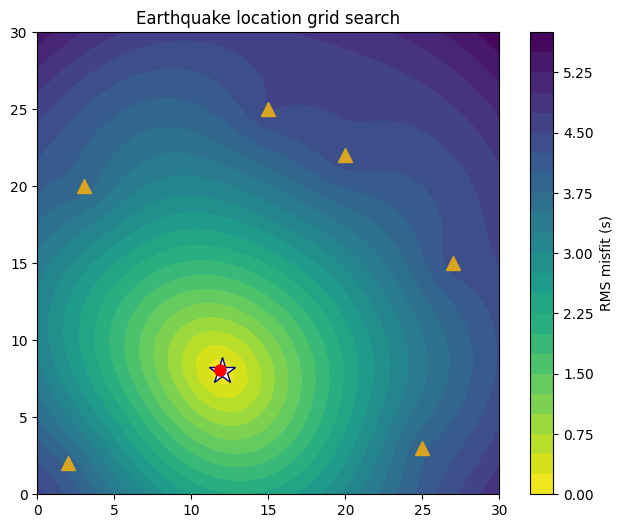

In [6]:
xg = np.linspace(0, 30, 150)
yg = np.linspace(0, 30, 150)
XX, YY = np.meshgrid(xg, yg)
misfit = np.zeros_like(XX)
for k in range(len(stations)):
    pred = np.sqrt((XX - stations[k, 0])**2 + (YY - stations[k, 1])**2) / v
    misfit += (t_obs[k] - pred) ** 2

best_idx = np.unravel_index(np.argmin(misfit), misfit.shape)
best_loc_grid = np.array([XX[best_idx], YY[best_idx]])
print(f"Grid search best-fit location: {best_loc_grid}")
print(f"True location:                 {true_loc}")
print(f"Error: {np.linalg.norm(best_loc_grid - true_loc):.3f} km")

plt.contourf(XX, YY, np.sqrt(misfit), levels=25, cmap="viridis_r")
plt.colorbar(label="RMS misfit (s)")
plt.plot(*true_loc, "*", color="white", markersize=20, markeredgecolor="navy")
plt.plot(*best_loc_grid, "o", color="red", markersize=8)
plt.plot(stations[:, 0], stations[:, 1], "^", color="goldenrod", markersize=10)
plt.gca().set_aspect("equal")
plt.title("Earthquake location grid search")
plt.show()

## Part 3 — The Linearized (Gauss-Newton) Alternative

A grid search over a fine 2-D grid was cheap here, but scales terribly to 4 parameters (T0, x, y, z) at realistic resolution. Let's implement the linearized iterative approach from lecture instead: starting from a guess, repeatedly solve for a small location update using the local derivative (Jacobian) of predicted travel time.

In [7]:
def predicted_times(loc, t0, stations, v):
    return t0 + np.linalg.norm(stations - loc, axis=1) / v

def jacobian(loc, stations, v):
    """d(t_pred)/d(x,y) for each station -- the G matrix for one Gauss-Newton step."""
    diffs = loc - stations           # (n_stations, 2)
    dists = np.linalg.norm(diffs, axis=1, keepdims=True)
    dists = np.maximum(dists, 1e-6)  # avoid divide-by-zero
    return diffs / (dists * v)       # (n_stations, 2): d(t)/d(x), d(t)/d(y)

In [8]:
# Start from a poor initial guess
m = np.array([5.0, 5.0])   # (x, y); assume T0=0 known for this simplified demo
history = [m.copy()]

for iteration in range(8):
    t_pred = predicted_times(m, 0.0, stations, v)
    residuals = t_obs - t_pred
    G_iter = jacobian(m, stations, v)
    dm, *_ = np.linalg.lstsq(G_iter, residuals, rcond=None)
    m = m + dm
    history.append(m.copy())
    print(f"Iteration {iteration+1}: location = {np.round(m, 3)}, "
          f"|dm| = {np.linalg.norm(dm):.4f} km")

history = np.array(history)
print(f"\nFinal location: {m}")
print(f"True location:  {true_loc}")
print(f"Error: {np.linalg.norm(m - true_loc):.4f} km")

Iteration 1: location = [12.329  6.954], |dm| = 7.5846 km
Iteration 2: location = [11.97   7.958], |dm| = 1.0658 km
Iteration 3: location = [11.977  7.959], |dm| = 0.0073 km
Iteration 4: location = [11.977  7.959], |dm| = 0.0000 km
Iteration 5: location = [11.977  7.959], |dm| = 0.0000 km
Iteration 6: location = [11.977  7.959], |dm| = 0.0000 km
Iteration 7: location = [11.977  7.959], |dm| = 0.0000 km
Iteration 8: location = [11.977  7.959], |dm| = 0.0000 km

Final location: [11.97675556  7.9588181 ]
True location:  [12.  8.]
Error: 0.0473 km


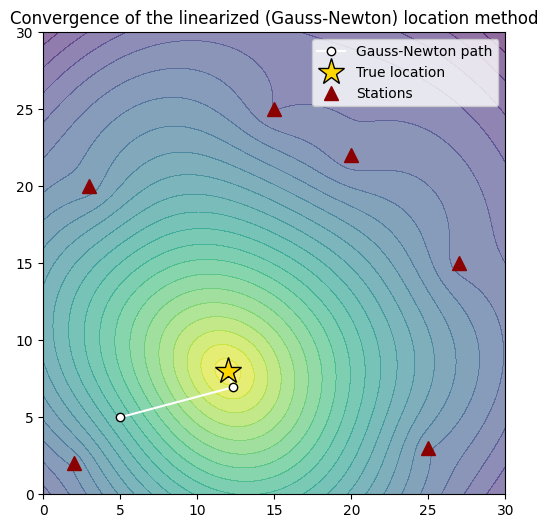

In [9]:
plt.contourf(XX, YY, np.sqrt(misfit), levels=25, cmap="viridis_r", alpha=0.6)
plt.plot(history[:, 0], history[:, 1], "o-", color="white", markeredgecolor="black", label="Gauss-Newton path")
plt.plot(*true_loc, "*", color="gold", markersize=20, markeredgecolor="black", label="True location")
plt.plot(stations[:, 0], stations[:, 1], "^", color="darkred", markersize=10, label="Stations")
plt.legend()
plt.gca().set_aspect("equal")
plt.title("Convergence of the linearized (Gauss-Newton) location method")
plt.show()

The iterative method converges to essentially the same location as the brute-force grid search, in just a handful of steps — and this approach scales linearly (not exponentially) as more model parameters are added, which is exactly why it's preferred for real 4-D (T0, x, y, z) earthquake location.

## Part 4 — Why Relative Location Wins

Now let's demonstrate the core claim from lecture: unmodeled 3-D structure biases nearby events in *nearly the same way*, so their travel-time residuals are correlated — and differencing them out gives much better relative precision than either event's absolute location alone.

In [10]:
# Two nearby "true" earthquakes
event_A = np.array([12.0, 8.0])
event_B = np.array([12.3, 8.2])   # 0.36 km away from A
true_separation = np.linalg.norm(event_B - event_A)
print(f"True separation: {true_separation:.3f} km")

# The real (unknown) velocity differs from the velocity we assume for location --
# a stand-in for unmodeled 3-D structure along the source-station paths.
v_true = 6.3      # km/s, unknown in practice
v_assumed = 6.0   # km/s, what we use to locate

rng2 = np.random.default_rng(4)
pick_noise = 0.01
t_obs_A = np.linalg.norm(stations - event_A, axis=1) / v_true + rng2.normal(0, pick_noise, len(stations))
t_obs_B = np.linalg.norm(stations - event_B, axis=1) / v_true + rng2.normal(0, pick_noise, len(stations))

True separation: 0.361 km


In [11]:
def locate_grid(t_obs_local, v_use):
    misfit_local = np.zeros_like(XX)
    for k in range(len(stations)):
        pred = np.sqrt((XX - stations[k, 0])**2 + (YY - stations[k, 1])**2) / v_use
        misfit_local += (t_obs_local[k] - pred) ** 2
    idx = np.unravel_index(np.argmin(misfit_local), misfit_local.shape)
    return np.array([XX[idx], YY[idx]])

# Absolute locations, using the (wrong) assumed velocity -- exactly what
# routine catalog locations do when the true 3-D structure is unmodeled.
loc_A_abs = locate_grid(t_obs_A, v_assumed)
loc_B_abs = locate_grid(t_obs_B, v_assumed)
abs_separation = np.linalg.norm(loc_B_abs - loc_A_abs)

print(f"Absolute location A: {loc_A_abs}  (true: {event_A}, error: {np.linalg.norm(loc_A_abs-event_A):.3f} km)")
print(f"Absolute location B: {loc_B_abs}  (true: {event_B}, error: {np.linalg.norm(loc_B_abs-event_B):.3f} km)")
print(f"Absolute-location separation: {abs_separation:.3f} km  (true: {true_separation:.3f} km)")

Absolute location A: [12.28187919  8.45637584]  (true: [12.  8.], error: 0.536 km)
Absolute location B: [12.48322148  8.65771812]  (true: [12.3  8.2], error: 0.493 km)
Absolute-location separation: 0.285 km  (true: 0.361 km)


In [12]:
# Relative location: use DIFFERENTIAL times (B relative to A). Since both
# events are close together, the SAME velocity error affects both of their
# absolute travel times almost identically -- so it largely cancels here,
# even though we still only use the same (wrong) assumed velocity.
t_rel = t_obs_B - t_obs_A

def locate_relative(t_rel_local, master_loc, v_use):
    """Grid search on the differential-time misfit relative to a fixed master location."""
    misfit_local = np.zeros_like(XX)
    for k in range(len(stations)):
        pred_A = np.linalg.norm(master_loc - stations[k]) / v_use
        pred_B = np.sqrt((XX - stations[k, 0])**2 + (YY - stations[k, 1])**2) / v_use
        misfit_local += (t_rel_local[k] - (pred_B - pred_A)) ** 2
    idx = np.unravel_index(np.argmin(misfit_local), misfit_local.shape)
    return np.array([XX[idx], YY[idx]])

loc_B_rel = locate_relative(t_rel, event_A, v_assumed)  # master event A assumed at its true location
rel_separation = np.linalg.norm(loc_B_rel - event_A)
print(f"Relative location of B (from master A): {loc_B_rel}")
print(f"Relative-location separation: {rel_separation:.3f} km  (true: {true_separation:.3f} km)")

print(f"\nAbsolute-method separation error: {abs(abs_separation - true_separation):.3f} km")
print(f"Relative-method separation error: {abs(rel_separation - true_separation):.3f} km")
assert abs(rel_separation - true_separation) < abs(abs_separation - true_separation)
print("Relative location gives the more accurate separation, despite using the same wrong velocity.")

Relative location of B (from master A): [12.28187919  8.25503356]
Relative-location separation: 0.380 km  (true: 0.361 km)

Absolute-method separation error: 0.076 km
Relative-method separation error: 0.020 km
Relative location gives the more accurate separation, despite using the same wrong velocity.


Even with a substantial shared station bias (representing unmodeled 3-D structure), the *relative* separation between the two events is recovered far more accurately than trying to difference their independently-biased absolute locations — exactly the argument lecture makes for why relative and double-difference relocation methods reveal much finer fault structure than routine catalog locations.

## Summary & Further Resources

- **Checkerboard tests** — a direct, quantitative way to see how ray geometry controls tomographic resolution; correlation with the true model is a simple, useful metric.
- **Grid search** — robust and simple, but scales exponentially with the number of model parameters.
- **Gauss-Newton iteration** — linearizes the nonlinear location problem and converges in a handful of steps, scaling linearly instead.
- **Relative location** — differencing out shared, unmodeled structure gives dramatically better *relative* precision between nearby events, even when neither absolute location is very accurate.

**For further reading:**
- Aster, R. C., B. Borchers, and C. H. Thurber, *Parameter Estimation and Inverse Problems* — grid search, Gauss-Newton, and resolution/checkerboard analysis.
- Waldhauser, F., and W. L. Ellsworth (2000), *A double-difference earthquake location algorithm* — the standard modern relative-location method, generalizing the two-event demonstration above to large earthquake catalogs.
- Lin, G., P. M. Shearer, and E. Hauksson (2007) — a real-world demonstration of how much finer fault structure relative relocation methods reveal (referenced in this lecture's slides).